### Explicação da célula — Importação de bibliotecas e definição dos caminhos

Esta célula prepara o ambiente de trabalho do notebook. São importadas as bibliotecas necessárias para manipulação dos dados, como `pandas` e `numpy`, além da biblioteca `os`, utilizada para criar diretórios e organizar os arquivos de saída.

Também são definidos os caminhos principais do projeto:

* `DADOS`: pasta onde estão armazenados os arquivos CSV utilizados na análise;
* `OUTPUT`: pasta onde serão salvos os resultados gerados;
* `TABELAS`: subpasta específica para armazenar tabelas produzidas durante a etapa de reestruturação da rede.

A criação automática da pasta `output/tabelas` garante que os arquivos resultantes possam ser salvos sem erro, mantendo a organização do projeto.

In [2]:
import os
import pandas as pd
import numpy as np

DADOS = '../dados'
OUTPUT = '../output'
TABELAS = f'{OUTPUT}/tabelas'

os.makedirs(TABELAS, exist_ok=True)

### Explicação da célula — Carregamento das bases de hospitais e sobrecarga

Esta célula carrega duas bases fundamentais para a etapa de reestruturação da rede.

A primeira base, `hospitais_ativos_CE_2024_geocodificados.csv`, contém todos os hospitais ativos no Ceará em 2024, já com nome, CNES, porte hospitalar, latitude e longitude.

A segunda base, `hospitais_sobrecarregados_rede_pulmao_2024.csv`, contém a classificação dos hospitais que foram identificados como sobrecarregados na rede atual de internações por câncer de pulmão.

Após o carregamento, os códigos CNES são padronizados para garantir que o cruzamento entre as bases ocorra corretamente. Essa padronização é importante porque o CNES funciona como identificador único de cada hospital.


In [2]:
df_hospitais = pd.read_csv(
    f'{DADOS}/hospitais_ativos_CE_2024_geocodificados.csv'
)

df_sobre = pd.read_csv(
    f'{DADOS}/hospitais_sobrecarregados_rede_pulmao_2024.csv'
)

def padronizar_cnes(df, coluna='CNES'):
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
        .str.zfill(7)
    )
    return df

df_hospitais = padronizar_cnes(df_hospitais, 'CNES')
df_sobre = padronizar_cnes(df_sobre, 'CNES')

### Explicação da célula — Identificação dos hospitais sobrecarregados

Esta célula cria a lista dos hospitais classificados como sobrecarregados na rede de câncer de pulmão.

A partir da base de sobrecarga, são selecionados os CNES dos hospitais em que a coluna `SOBRECARREGADO` é verdadeira. Em seguida, essa informação é adicionada à base geral de hospitais ativos por meio da nova coluna `SOBRECARREGADO_REDE_PULMAO`.

Essa coluna indica se cada hospital ativo em 2024 está ou não sobrecarregado na rede atual de internações por câncer de pulmão.

Essa etapa é importante porque os hospitais sobrecarregados não são excluídos da análise, mas deixam de ser considerados como candidatos para absorver nova demanda na simulação de redistribuição. Eles continuam representando polos centrais da rede atual.


In [3]:
cnes_sobrecarregados = df_sobre[
    df_sobre['SOBRECARREGADO'] == True
]['CNES'].tolist()

df_hospitais['SOBRECARREGADO_REDE_PULMAO'] = df_hospitais['CNES'].isin(
    cnes_sobrecarregados
)

print('Hospitais ativos:', len(df_hospitais))
print('Hospitais sobrecarregados:', df_hospitais['SOBRECARREGADO_REDE_PULMAO'].sum())

df_hospitais[
    df_hospitais['SOBRECARREGADO_REDE_PULMAO'] == True
][['CNES', 'HOSPITAL', 'PORTE', 'Latitude', 'Longitude']]

Hospitais ativos: 238
Hospitais sobrecarregados: 12


,CNES,HOSPITAL,PORTE,Latitude,Longitude
7,2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Grande,-3.815540,-38.501380
29,2333813,SOCIEDADE HOSPITALAR PE DIONISIO,Pequeno,-4.419083,-39.044801
34,2611201,HOSPITAL MUNICIPAL SENADOR CARLOS JEREISSATI,Pequeno,-5.308903,-38.922604
69,2415496,HOSPITAL SAO RAIMUNDO,Medio,-3.730766,-38.506261
80,2723220,HOSPITAL HAROLDO JUACABA,Medio,-3.747382,-38.553531
145,2527707,HOSPITAL SAO RAIMUNDO,Medio,-3.730766,-38.506261
150,2554798,HOSP MUNICIPAL DR ARGEU BRAGA HERBSTER,Pequeno,-3.879736,-38.676852
164,2664151,HOSPITAL MUNICIPAL SENADOR CARLOS JEREISSATI,Pequeno,-5.308903,-38.922604
189,2328402,HOSPITAL MUNICIPAL DR EUDASIO BARROSO HMEB,Pequeno,-4.968439,-39.016031
197,2328003,HOSPITAL E CASA DE SAUDE DE RUSSAS,Medio,-4.938011,-37.969516


### Explicação da célula — Salvamento da base de hospitais com sobrecarga

Esta célula salva a base consolidada de hospitais ativos com a informação de sobrecarga.

O arquivo gerado, `hospitais_ativos_CE_2024_com_sobrecarga.csv`, passa a reunir em uma única tabela as principais informações hospitalares necessárias para as próximas etapas:

* CNES;
* nome do hospital;
* porte hospitalar;
* latitude;
* longitude;
* indicação de sobrecarga na rede de câncer de pulmão.

Esse arquivo é importante porque evita a necessidade de refazer os cruzamentos anteriores em etapas futuras do notebook.

In [4]:
df_hospitais.to_csv(
    f'{DADOS}/hospitais_ativos_CE_2024_com_sobrecarga.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Base de hospitais ativos com sobrecarga salva com sucesso.')

Base de hospitais ativos com sobrecarga salva com sucesso.


### Explicação da célula — Criação da base inicial de candidatos

Esta célula cria a base inicial de hospitais candidatos à redistribuição da demanda.

A partir da base de hospitais ativos, são selecionados apenas os hospitais que não foram classificados como sobrecarregados na rede de câncer de pulmão. A lógica é que hospitais já pressionados pela demanda atual não devem ser escolhidos como alternativas para receber ainda mais pacientes.

Assim, a base `df_candidatos_base` representa o conjunto inicial de hospitais elegíveis para a etapa de seleção de candidatos, antes da aplicação dos filtros por tipo de procedimento.


In [5]:
df_candidatos_base = df_hospitais[
    df_hospitais['SOBRECARREGADO_REDE_PULMAO'] == False
].copy()

print('Hospitais ativos:', len(df_hospitais))
print('Hospitais não elegíveis por sobrecarga:', df_hospitais['SOBRECARREGADO_REDE_PULMAO'].sum())
print('Candidatos base:', len(df_candidatos_base))

Hospitais ativos: 238
Hospitais não elegíveis por sobrecarga: 12
Candidatos base: 226


### Explicação da célula — Função de filtragem por tipo de procedimento

Esta célula define uma função responsável por filtrar os hospitais candidatos conforme o tipo de procedimento analisado.

A função considera que diferentes tipos de atendimento exigem diferentes níveis de estrutura hospitalar. Por isso, os hospitais são filtrados com base no porte:

* para intercorrências, são aceitos hospitais pequenos, médios, grandes e especiais;
* para tratamento clínico, são aceitos hospitais médios, grandes e especiais;
* para cirurgias, são aceitos apenas hospitais grandes e especiais.

Esse filtro evita que o modelo indique hospitais inadequados para procedimentos de maior complexidade apenas por estarem geograficamente próximos.


In [6]:
def filtrar_candidatos_por_tipo(df, tipo_proc):
    df = df.copy()

    if tipo_proc == 'Intercorrencia':
        portes_validos = ['Pequeno', 'Medio', 'Grande', 'Especial']

    elif tipo_proc == 'Tratamento Clinico':
        portes_validos = ['Medio', 'Grande', 'Especial']

    elif tipo_proc == 'Cirurgia':
        portes_validos = ['Grande', 'Especial']

    else:
        raise ValueError('Tipo de procedimento inválido.')

    return df[df['PORTE'].isin(portes_validos)].copy()

### Explicação da célula — Aplicação dos filtros e contagem dos candidatos

Esta célula aplica a função de filtragem aos três tipos de procedimento analisados na pesquisa: intercorrência, tratamento clínico e cirurgia.

Como resultado, são criadas três bases distintas de candidatos:

* `df_cand_intercorrencia`;
* `df_cand_tratamento`;
* `df_cand_cirurgia`.

A contagem final mostra quantos hospitais permanecem elegíveis para cada tipo de atendimento. Essa diferença entre os grupos é importante metodologicamente, pois demonstra que procedimentos de maior complexidade tendem a ter menos alternativas hospitalares disponíveis.

In [7]:
df_cand_intercorrencia = filtrar_candidatos_por_tipo(
    df_candidatos_base,
    'Intercorrencia'
)

df_cand_tratamento = filtrar_candidatos_por_tipo(
    df_candidatos_base,
    'Tratamento Clinico'
)

df_cand_cirurgia = filtrar_candidatos_por_tipo(
    df_candidatos_base,
    'Cirurgia'
)

print('Candidatos para intercorrência:', len(df_cand_intercorrencia))
print('Candidatos para tratamento clínico:', len(df_cand_tratamento))
print('Candidatos para cirurgia:', len(df_cand_cirurgia))

Candidatos para intercorrência: 226
Candidatos para tratamento clínico: 93
Candidatos para cirurgia: 23


### Explicação da célula — Salvamento dos hospitais candidatos

Esta célula salva os três conjuntos de hospitais candidatos em arquivos CSV separados.

Os arquivos gerados são:

* `candidatos_intercorrencia_2024.csv`;
* `candidatos_tratamento_clinico_2024.csv`;
* `candidatos_cirurgia_2024.csv`.

Esses arquivos serão utilizados nas próximas etapas da pesquisa para comparar a localização dos hospitais candidatos com os municípios mais impactados e, posteriormente, para simular a redistribuição da demanda.

In [8]:
df_cand_intercorrencia.to_csv(
    f'{DADOS}/candidatos_intercorrencia_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_cand_tratamento.to_csv(
    f'{DADOS}/candidatos_tratamento_clinico_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_cand_cirurgia.to_csv(
    f'{DADOS}/candidatos_cirurgia_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Arquivos de candidatos salvos com sucesso.')

Arquivos de candidatos salvos com sucesso.


### Explicação da célula — Carregamento dos dados de internações por câncer de pulmão

Esta célula carrega novamente a base de internações por câncer de pulmão em 2024, além das bases auxiliares de hospitais e municípios.

A base `dados_sih_2024_pulmao.csv` contém os registros de internação filtrados pelo diagnóstico de câncer de pulmão. Já os arquivos `CNESBR.csv` e `MUNICSBR.csv` são utilizados para recuperar, respectivamente, os nomes dos hospitais e os nomes dos municípios de residência dos pacientes.

Essa etapa prepara os dados necessários para construir os fluxos reais entre municípios e hospitais.


In [9]:
df_pulmao = pd.read_csv(f'{DADOS}/dados_sih_2024_pulmao.csv', low_memory=False)
cnes_mapping = pd.read_csv(f'{DADOS}/CNESBR.csv')
munic_mapping = pd.read_csv(f'{DADOS}/MUNICSBR.csv')

### Explicação da célula — Padronização dos códigos CNES e dos municípios

Esta célula padroniza os códigos utilizados para cruzar as bases.

O CNES dos hospitais é convertido para texto e ajustado para manter sete dígitos, evitando inconsistências causadas por leitura numérica dos arquivos CSV. Também são padronizados os códigos dos municípios de residência dos pacientes e os códigos da base de municípios.

Essa etapa é essencial para garantir que os cruzamentos posteriores entre internações, hospitais e municípios sejam feitos corretamente.

In [10]:
def padronizar_cnes(df, coluna='CNES'):
    df[coluna] = (
        df[coluna]
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
        .str.zfill(7)
    )
    return df

df_pulmao = padronizar_cnes(df_pulmao, 'CNES')
cnes_mapping = padronizar_cnes(cnes_mapping, 'CNES')

df_pulmao['MUNIC_RES'] = df_pulmao['MUNIC_RES'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
munic_mapping['COD'] = munic_mapping['COD'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()

### Explicação da célula — Inclusão dos nomes de hospitais e municípios

Esta célula verifica se a base de internações já possui as colunas `HOSPITAL` e `MUNICIPIO`.

Caso essas colunas não existam, elas são adicionadas por meio de cruzamentos com as bases auxiliares:

* o nome do hospital é obtido a partir do CNES;
* o nome do município é obtido a partir do código de residência do paciente.

Ao final, a visualização das colunas principais confirma que cada internação possui município de origem, hospital de destino e tipo de procedimento.

In [11]:
if 'HOSPITAL' not in df_pulmao.columns:
    df_pulmao = df_pulmao.merge(
        cnes_mapping.rename(columns={'NOMEFANT': 'HOSPITAL'})[['CNES', 'HOSPITAL']],
        on='CNES',
        how='left'
    )

if 'MUNICIPIO' not in df_pulmao.columns:
    df_pulmao = df_pulmao.merge(
        munic_mapping.rename(columns={'COD': 'MUNIC_RES', 'MUNIC': 'MUNICIPIO'})[['MUNIC_RES', 'MUNICIPIO']],
        on='MUNIC_RES',
        how='left'
    )

print(df_pulmao[['MUNIC_RES', 'MUNICIPIO', 'CNES', 'HOSPITAL', 'TIPO_PROC']].head())

  MUNIC_RES            MUNICIPIO     CNES  \
0    230440        FORTALEZA, CE  2479214   
1    230765        MARACANAU, CE  2479214   
2    230440        FORTALEZA, CE  2479214   
3    231090  PIQUET CARNEIRO, CE  2479214   
4    231050     PEDRA BRANCA, CE  2479214   

                                            HOSPITAL           TIPO_PROC  
0  HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...  Tratamento Clinico  
1  HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...  Tratamento Clinico  
2  HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...  Tratamento Clinico  
3  HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...  Tratamento Clinico  
4  HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...  Tratamento Clinico  


### Explicação da célula — Carregamento da base de hospitais com sobrecarga

Esta célula carrega a base consolidada de hospitais ativos com a informação de sobrecarga.

A base `hospitais_ativos_CE_2024_com_sobrecarga.csv` contém a coluna `SOBRECARREGADO_REDE_PULMAO`, que será usada para identificar se cada fluxo de internação está direcionado para um hospital sobrecarregado.

Essa etapa é necessária porque, para avaliar o impacto sobre os municípios, não basta saber para qual hospital o paciente foi encaminhado. Também é necessário saber se esse hospital já está pressionado na rede atual.


In [12]:
df_hospitais = pd.read_csv(
    f'{DADOS}/hospitais_ativos_CE_2024_com_sobrecarga.csv'
)

df_hospitais = padronizar_cnes(df_hospitais, 'CNES')

df_hospitais[['CNES', 'HOSPITAL', 'PORTE', 'SOBRECARREGADO_REDE_PULMAO']].head()

,CNES,HOSPITAL,PORTE,SOBRECARREGADO_REDE_PULMAO
0,9672427,HOSPITAL REGIONAL VALE DO JAGUARIBE,Medio,False
1,2561417,HOSPITAL SAO JOSE DE DOENCAS INFECCIOSAS,Medio,False
2,2480026,HOSPITAL DE SAUDE MENTAL DE MESSEJANA,Grande,False
3,7061021,HOSPITAL REGIONAL DO SERTAO CENTRAL,Grande,False
4,6848710,HOSPITAL REGIONAL NORTE,Grande,False


## Criação dos Fluxos Município-Hospital

A partir desta etapa, a análise deixa de olhar para internações individuais e passa a representar os deslocamentos assistenciais como fluxos entre municípios e hospitais.

Cada fluxo representa uma relação entre o município de residência do paciente e o hospital onde ocorreu a internação. Essa estrutura é essencial para identificar quais municípios dependem mais dos hospitais centrais ou sobrecarregados.


### Explicação da célula — Criação dos fluxos município-hospital

Esta célula agrupa os registros de internação por município de residência, hospital de destino e tipo de procedimento.

O resultado é a tabela `df_fluxos`, em que cada linha representa um fluxo assistencial específico, e a coluna `INTERNACOES` indica quantas internações ocorreram naquele fluxo.

Por exemplo, se pacientes de um determinado município foram internados várias vezes no mesmo hospital para tratamento clínico, essas internações passam a ser representadas por uma única linha com o total correspondente.

Essa tabela é a base para analisar a dependência territorial da rede de atendimento ao câncer de pulmão.

In [13]:
df_fluxos = (
    df_pulmao
    .groupby(['MUNIC_RES', 'MUNICIPIO', 'CNES', 'HOSPITAL', 'TIPO_PROC'])
    .size()
    .reset_index(name='INTERNACOES')
)

print('Total de fluxos município-hospital:', len(df_fluxos))
df_fluxos.head(10)

Total de fluxos município-hospital: 339


,MUNIC_RES,MUNICIPIO,CNES,HOSPITAL,TIPO_PROC,INTERNACOES
0,130260,"MANAUS, AM",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,1
1,230010,"ABAIARA, CE",2564211,HOSPITAL MATERNIDADE SAO VICENTE DE PAULO HMSVP,Tratamento Clinico,1
2,230015,"ACARAPE, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2
3,230020,"ACARAU, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2
4,230020,"ACARAU, CE",2516632,HOSP DR MOURA FERREIRA,Tratamento Clinico,7
5,230020,"ACARAU, CE",3021114,SANTA CASA DE MISERICORDIA DE SOBRAL,Tratamento Clinico,1
6,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Intercorrencia,1
7,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Tratamento Clinico,5
8,230040,"AIUABA, CE",2528843,HOSPITAL DISTRITAL DR FERNANDES TAVORA,Tratamento Clinico,1
9,230060,"ALTANEIRA, CE",2497654,HGF HOSPITAL GERAL DE FORTALEZA,Tratamento Clinico,1


### Explicação da célula — Associação da sobrecarga aos fluxos

Esta célula adiciona aos fluxos a informação sobre a condição do hospital de destino.

A partir do CNES, cada fluxo município-hospital recebe a coluna `SOBRECARREGADO_REDE_PULMAO`, indicando se o hospital para o qual os pacientes foram encaminhados está ou não sobrecarregado.

Essa informação permite medir quais municípios enviam mais pacientes para hospitais já pressionados pela demanda da rede atual.

In [14]:
hosp_sobrecarga = df_hospitais[
    ['CNES', 'PORTE', 'SOBRECARREGADO_REDE_PULMAO']
].copy()

df_fluxos = df_fluxos.merge(
    hosp_sobrecarga,
    on='CNES',
    how='left'
)

df_fluxos['SOBRECARREGADO_REDE_PULMAO'] = (
    df_fluxos['SOBRECARREGADO_REDE_PULMAO']
    .fillna(False)
)

df_fluxos.head(10)

,MUNIC_RES,MUNICIPIO,CNES,HOSPITAL,TIPO_PROC,INTERNACOES,PORTE,SOBRECARREGADO_REDE_PULMAO
0,130260,"MANAUS, AM",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,1,Grande,True
1,230010,"ABAIARA, CE",2564211,HOSPITAL MATERNIDADE SAO VICENTE DE PAULO HMSVP,Tratamento Clinico,1,Grande,False
2,230015,"ACARAPE, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2,Grande,True
3,230020,"ACARAU, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2,Grande,True
4,230020,"ACARAU, CE",2516632,HOSP DR MOURA FERREIRA,Tratamento Clinico,7,Medio,False
5,230020,"ACARAU, CE",3021114,SANTA CASA DE MISERICORDIA DE SOBRAL,Tratamento Clinico,1,Grande,False
6,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Intercorrencia,1,Medio,False
7,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Tratamento Clinico,5,Medio,False
8,230040,"AIUABA, CE",2528843,HOSPITAL DISTRITAL DR FERNANDES TAVORA,Tratamento Clinico,1,Grande,False
9,230060,"ALTANEIRA, CE",2497654,HGF HOSPITAL GERAL DE FORTALEZA,Tratamento Clinico,1,Especial,False


### Explicação da célula — Criação da coluna de internações para hospitais sobrecarregados

Esta célula cria a coluna `INTERNACOES_SOBRECARREGADO`.

Ela recebe o valor de `INTERNACOES` apenas nos fluxos cujo hospital de destino está classificado como sobrecarregado. Quando o hospital de destino não está sobrecarregado, o valor da coluna é zero.

Essa transformação facilita o cálculo posterior dos municípios mais impactados, pois separa automaticamente as internações direcionadas para hospitais sobrecarregados das demais internações.

In [15]:
df_fluxos['INTERNACOES_SOBRECARREGADO'] = np.where(
    df_fluxos['SOBRECARREGADO_REDE_PULMAO'] == True,
    df_fluxos['INTERNACOES'],
    0
)

df_fluxos.head(10)

,MUNIC_RES,MUNICIPIO,CNES,HOSPITAL,TIPO_PROC,INTERNACOES,PORTE,SOBRECARREGADO_REDE_PULMAO,INTERNACOES_SOBRECARREGADO
0,130260,"MANAUS, AM",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,1,Grande,True,1
1,230010,"ABAIARA, CE",2564211,HOSPITAL MATERNIDADE SAO VICENTE DE PAULO HMSVP,Tratamento Clinico,1,Grande,False,0
2,230015,"ACARAPE, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2,Grande,True,2
3,230020,"ACARAU, CE",2479214,HM HOSPITAL DE MESSEJANA DR CARLOS ALBERTO STU...,Tratamento Clinico,2,Grande,True,2
4,230020,"ACARAU, CE",2516632,HOSP DR MOURA FERREIRA,Tratamento Clinico,7,Medio,False,0
5,230020,"ACARAU, CE",3021114,SANTA CASA DE MISERICORDIA DE SOBRAL,Tratamento Clinico,1,Grande,False,0
6,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Intercorrencia,1,Medio,False,0
7,230030,"ACOPIARA, CE",9275134,HOSPITAL MUNICIPAL DE ACOPIARA PADRE CRISARES ...,Tratamento Clinico,5,Medio,False,0
8,230040,"AIUABA, CE",2528843,HOSPITAL DISTRITAL DR FERNANDES TAVORA,Tratamento Clinico,1,Grande,False,0
9,230060,"ALTANEIRA, CE",2497654,HGF HOSPITAL GERAL DE FORTALEZA,Tratamento Clinico,1,Especial,False,0


### Explicação da célula — Identificação dos municípios impactados

Esta célula cria a tabela de municípios impactados pela concentração da rede atual.

Os fluxos são agrupados por município de residência, calculando:

* o total de internações de pacientes daquele município;
* o total de internações direcionadas para hospitais sobrecarregados;
* a quantidade de hospitais diferentes para os quais o município enviou pacientes;
* o percentual de internações direcionadas para hospitais sobrecarregados.

A tabela final é ordenada de forma a destacar os municípios com maior dependência de hospitais sobrecarregados. Essa etapa é central para a pesquisa, pois identifica quais territórios sofrem maior impacto da concentração assistencial.

In [16]:
df_municipios_impactados = (
    df_fluxos
    .groupby(['MUNIC_RES', 'MUNICIPIO'])
    .agg(
        TOTAL_INTERNACOES=('INTERNACOES', 'sum'),
        INTERNACOES_PARA_SOBRECARREGADO=('INTERNACOES_SOBRECARREGADO', 'sum'),
        QTD_HOSPITAIS_DESTINO=('CNES', 'nunique')
    )
    .reset_index()
)

df_municipios_impactados['PERC_PARA_SOBRECARREGADO'] = (
    df_municipios_impactados['INTERNACOES_PARA_SOBRECARREGADO'] /
    df_municipios_impactados['TOTAL_INTERNACOES']
)

df_municipios_impactados = df_municipios_impactados.sort_values(
    ['INTERNACOES_PARA_SOBRECARREGADO', 'TOTAL_INTERNACOES'],
    ascending=False
)

df_municipios_impactados.head(20)

,MUNIC_RES,MUNICIPIO,TOTAL_INTERNACOES,INTERNACOES_PARA_SOBRECARREGADO,QTD_HOSPITAIS_DESTINO,PERC_PARA_SOBRECARREGADO
43,230440,"FORTALEZA, CE",511,412,13,0.806262
35,230370,"CAUCAIA, CE",44,36,7,0.818182
78,230765,"MARACANAU, CE",46,29,5,0.630435
110,231180,"RUSSAS, CE",29,27,5,0.931034
42,230428,"EUSEBIO, CE",21,19,3,0.904762
79,230770,"MARANGUAPE, CE",17,16,3,0.941176
125,231330,"TAUA, CE",17,15,5,0.882353
66,230640,"ITAPIPOCA, CE",18,13,2,0.722222
32,230350,"CASCAVEL, CE",13,12,2,0.923077
64,230625,"ITAITINGA, CE",13,11,3,0.846154


### Explicação da célula — Salvamento da tabela de municípios impactados

Esta célula salva a tabela final de municípios impactados no arquivo `municipios_impactados_2024.csv`, dentro da pasta `output/tabelas`.

Esse arquivo será utilizado nas próximas etapas para selecionar os municípios prioritários da simulação e comparar suas distâncias em relação aos hospitais candidatos.

A tabela salva representa um dos principais resultados intermediários da pesquisa, pois indica quais municípios devem ser priorizados em uma proposta de reorganização regional da assistência ao câncer de pulmão.


In [17]:
df_municipios_impactados.to_csv(
    f'{TABELAS}/municipios_impactados_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Tabela de municípios impactados salva com sucesso.')

Tabela de municípios impactados salva com sucesso.


In [18]:
df_municipios_impactados.head(20)

,MUNIC_RES,MUNICIPIO,TOTAL_INTERNACOES,INTERNACOES_PARA_SOBRECARREGADO,QTD_HOSPITAIS_DESTINO,PERC_PARA_SOBRECARREGADO
43,230440,"FORTALEZA, CE",511,412,13,0.806262
35,230370,"CAUCAIA, CE",44,36,7,0.818182
78,230765,"MARACANAU, CE",46,29,5,0.630435
110,231180,"RUSSAS, CE",29,27,5,0.931034
42,230428,"EUSEBIO, CE",21,19,3,0.904762
79,230770,"MARANGUAPE, CE",17,16,3,0.941176
125,231330,"TAUA, CE",17,15,5,0.882353
66,230640,"ITAPIPOCA, CE",18,13,2,0.722222
32,230350,"CASCAVEL, CE",13,12,2,0.923077
64,230625,"ITAITINGA, CE",13,11,3,0.846154


## Visualização Espacial dos Municípios Impactados

O mapa de calor representa a distribuição espacial dos municípios de residência dos pacientes, ponderada pelo número de internações direcionadas a hospitais classificados como sobrecarregados. Portanto, as áreas mais intensas indicam regiões de origem com maior dependência da rede hospitalar sobrecarregada, e não necessariamente os locais de maior capacidade receptora.

Mais quente = região que mais envia pacientes para hospitais sobrecarregados.

Além do volume absoluto, a análise também considera a dependência proporcional dos municípios. Alguns municípios são impactados porque enviam muitos pacientes para hospitais sobrecarregados, enquanto outros, mesmo com menos internações, dependem quase totalmente desses hospitais. Assim, a visualização ajuda a identificar tanto regiões com maior pressão em quantidade quanto regiões com menor número de casos, mas com alta dependência da rede sobrecarregada.

exemplo das duas:

Cidade A:
100 pacientes;
80 vão para hospital sobrecarregado;
Dependência = 80% (exemplo de fortaleza)

Cidade B:
5 pacientes;
5 vão para hospital sobrecarregado;
Dependência = 100%  (mais critico e geralmente o que acontece em municipios menores)

In [19]:
import folium
from folium.plugins import HeatMap
import branca.colormap as cm
from normalize import normalizar_nome

geo_data = pd.read_csv(f'{DADOS}/geograf.csv')

df_municipios_mapa = df_municipios_impactados.copy()

df_municipios_mapa['MUNICIPIO_NORM'] = df_municipios_mapa['MUNICIPIO'].apply(normalizar_nome)

geo_municipios = geo_data.copy()
geo_municipios['NOME_NORM'] = geo_municipios['Nome'].apply(normalizar_nome)

geo_municipios = geo_municipios.rename(
    columns={
        'Latitude': 'LAT_MUNICIPIO',
        'Longitude': 'LON_MUNICIPIO'
    }
)

geo_municipios = geo_municipios[
    ['NOME_NORM', 'LAT_MUNICIPIO', 'LON_MUNICIPIO']
].drop_duplicates(subset=['NOME_NORM'])

df_municipios_mapa = df_municipios_mapa.merge(
    geo_municipios,
    left_on='MUNICIPIO_NORM',
    right_on='NOME_NORM',
    how='left'
)

df_municipios_mapa = df_municipios_mapa.drop(columns=['NOME_NORM'], errors='ignore')

print('Municípios impactados:', len(df_municipios_mapa))
print('Sem latitude:', df_municipios_mapa['LAT_MUNICIPIO'].isna().sum())
print('Sem longitude:', df_municipios_mapa['LON_MUNICIPIO'].isna().sum())

df_municipios_mapa.head()

Municípios impactados: 135
Sem latitude: 1
Sem longitude: 1


,MUNIC_RES,MUNICIPIO,TOTAL_INTERNACOES,INTERNACOES_PARA_SOBRECARREGADO,QTD_HOSPITAIS_DESTINO,PERC_PARA_SOBRECARREGADO,MUNICIPIO_NORM,LAT_MUNICIPIO,LON_MUNICIPIO
0,230440,"FORTALEZA, CE",511,412,13,0.806262,"FORTALEZA, CE",-3.732720,-38.527013
1,230370,"CAUCAIA, CE",44,36,7,0.818182,"CAUCAIA, CE",-3.728144,-38.661921
2,230765,"MARACANAU, CE",46,29,5,0.630435,"MARACANAU, CE",-3.868284,-38.626457
3,231180,"RUSSAS, CE",29,27,5,0.931034,"RUSSAS, CE",-4.941419,-37.976262
4,230428,"EUSEBIO, CE",21,19,3,0.904762,"EUSEBIO, CE",-3.889001,-38.454654


In [20]:
df_municipios_mapa.to_csv(
    f'{TABELAS}/municipios_impactados_com_coordenadas_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Tabela de municípios impactados com coordenadas salva com sucesso.')

Tabela de municípios impactados com coordenadas salva com sucesso.


In [21]:
df_heat = df_municipios_mapa.dropna(
    subset=['LAT_MUNICIPIO', 'LON_MUNICIPIO']
).copy()

df_heat = df_heat[
    df_heat['INTERNACOES_PARA_SOBRECARREGADO'] > 0
].copy()

heat_data = df_heat[
    ['LAT_MUNICIPIO', 'LON_MUNICIPIO', 'INTERNACOES_PARA_SOBRECARREGADO']
].values.tolist()

mapa_calor = folium.Map(
    location=[-5.2, -39.5],
    zoom_start=7,
    tiles='cartodbpositron'
)

HeatMap(
    heat_data,
    radius=30,
    blur=20,
    min_opacity=0.3,
    max_zoom=10
).add_to(mapa_calor)

mapa_calor.save(f'{OUTPUT}/mapa_calor_municipios_impactados_2024.html')

print('Mapa de calor salvo com sucesso.')

Mapa de calor salvo com sucesso.


In [22]:
df_pontos = df_municipios_mapa.dropna(
    subset=['LAT_MUNICIPIO', 'LON_MUNICIPIO']
).copy()

max_internacoes_sobre = df_pontos['INTERNACOES_PARA_SOBRECARREGADO'].max()

colormap = cm.linear.YlOrRd_09.scale(
    df_pontos['PERC_PARA_SOBRECARREGADO'].min(),
    df_pontos['PERC_PARA_SOBRECARREGADO'].max()
)

colormap.caption = 'Percentual de internações para hospitais sobrecarregados'

mapa_pontos = folium.Map(
    location=[-5.2, -39.5],
    zoom_start=7,
    tiles='cartodbpositron'
)

for _, row in df_pontos.iterrows():
    impacto_abs = row['INTERNACOES_PARA_SOBRECARREGADO']
    perc = row['PERC_PARA_SOBRECARREGADO']

    if max_internacoes_sobre > 0:
        raio = 5 + (np.sqrt(impacto_abs) / np.sqrt(max_internacoes_sobre)) * 25
    else:
        raio = 5

    popup = f"""
    <b>Município:</b> {row['MUNICIPIO']}<br>
    <b>Total de internações:</b> {row['TOTAL_INTERNACOES']}<br>
    <b>Internações para sobrecarregados:</b> {row['INTERNACOES_PARA_SOBRECARREGADO']}<br>
    <b>% para sobrecarregados:</b> {perc:.2%}<br>
    <b>Hospitais de destino:</b> {row['QTD_HOSPITAIS_DESTINO']}
    """

    folium.CircleMarker(
        location=[row['LAT_MUNICIPIO'], row['LON_MUNICIPIO']],
        radius=raio,
        popup=folium.Popup(popup, max_width=300),
        color=colormap(perc),
        fill=True,
        fill_color=colormap(perc),
        fill_opacity=0.7,
        weight=1
    ).add_to(mapa_pontos)

colormap.add_to(mapa_pontos)

mapa_pontos.save(f'{OUTPUT}/mapa_pontos_municipios_impactados_2024.html')

print('Mapa de pontos proporcionais salvo com sucesso.')

Mapa de pontos proporcionais salvo com sucesso.


In [23]:
df_ranking_mapa = df_municipios_mapa.sort_values(
    ['INTERNACOES_PARA_SOBRECARREGADO', 'PERC_PARA_SOBRECARREGADO'],
    ascending=False
)

df_ranking_mapa[
    [
        'MUNICIPIO',
        'TOTAL_INTERNACOES',
        'INTERNACOES_PARA_SOBRECARREGADO',
        'PERC_PARA_SOBRECARREGADO',
        'QTD_HOSPITAIS_DESTINO'
    ]
].head(20)

,MUNICIPIO,TOTAL_INTERNACOES,INTERNACOES_PARA_SOBRECARREGADO,PERC_PARA_SOBRECARREGADO,QTD_HOSPITAIS_DESTINO
0,"FORTALEZA, CE",511,412,0.806262,13
1,"CAUCAIA, CE",44,36,0.818182,7
2,"MARACANAU, CE",46,29,0.630435,5
3,"RUSSAS, CE",29,27,0.931034,5
4,"EUSEBIO, CE",21,19,0.904762,3
5,"MARANGUAPE, CE",17,16,0.941176,3
6,"TAUA, CE",17,15,0.882353,5
7,"ITAPIPOCA, CE",18,13,0.722222,2
8,"CASCAVEL, CE",13,12,0.923077,2
9,"ITAITINGA, CE",13,11,0.846154,3


## Associação dos Municípios Impactados aos Hospitais Candidatos Mais Próximos

Nesta etapa, os municípios impactados são comparados com os hospitais candidatos previamente selecionados. O objetivo é identificar, para cada município, quais hospitais candidatos estão geograficamente mais próximos, considerando separadamente os tipos de procedimento: intercorrência, tratamento clínico e cirurgia.

Essa etapa funciona como uma pré-seleção espacial antes da aplicação do algoritmo de Dijkstra. Inicialmente, utiliza-se a distância geográfica aproximada entre município e hospital. Posteriormente, essa distância poderá ser substituída pela distância real na malha viária.

In [24]:
df_municipios_mapa = pd.read_csv(
    f'{TABELAS}/municipios_impactados_com_coordenadas_2024.csv'
)

df_cand_intercorrencia = pd.read_csv(
    f'{DADOS}/candidatos_intercorrencia_2024.csv'
)

df_cand_tratamento = pd.read_csv(
    f'{DADOS}/candidatos_tratamento_clinico_2024.csv'
)

df_cand_cirurgia = pd.read_csv(
    f'{DADOS}/candidatos_cirurgia_2024.csv'
)

print('Municípios impactados:', len(df_municipios_mapa))
print('Candidatos intercorrência:', len(df_cand_intercorrencia))
print('Candidatos tratamento clínico:', len(df_cand_tratamento))
print('Candidatos cirurgia:', len(df_cand_cirurgia))

Municípios impactados: 135
Candidatos intercorrência: 226
Candidatos tratamento clínico: 93
Candidatos cirurgia: 23


## A fórmula de Haversine 
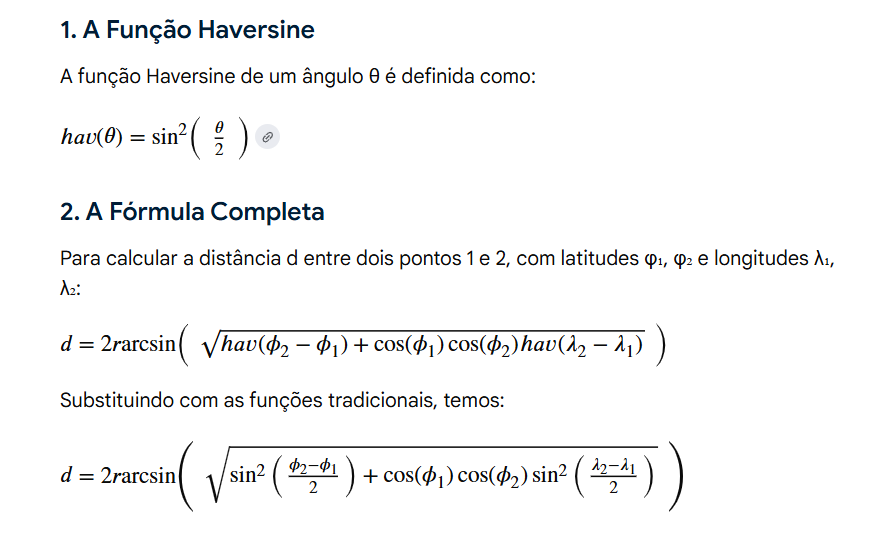

É uma equação matemática amplamente utilizada na navegação e na ciência de dados para calcular a distância geodésica aproximada entre dois pontos (o chamado "caminho do grande círculo") na superfície de uma esfera, usando suas coordenadas geográficas de latitude e longitude

In [25]:
from math import radians, sin, cos, sqrt, atan2

def haversine_km(lat1, lon1, lat2, lon2):
    R = 6371

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c

## Essa função pega cada município impactado e encontra os hospitais candidatos mais próximos para um determinado tipo de procedimento.

In [26]:
def candidatos_mais_proximos(df_municipios, df_candidatos, tipo_proc, top_n=3):
    resultados = []

    df_municipios_validos = df_municipios.dropna(
        subset=['LAT_MUNICIPIO', 'LON_MUNICIPIO']
    ).copy()

    df_candidatos_validos = df_candidatos.dropna(
        subset=['Latitude', 'Longitude']
    ).copy()

    for _, mun in df_municipios_validos.iterrows():
        candidatos = df_candidatos_validos.copy()

        candidatos['DISTANCIA_KM'] = candidatos.apply(
            lambda row: haversine_km(
                mun['LAT_MUNICIPIO'],
                mun['LON_MUNICIPIO'],
                row['Latitude'],
                row['Longitude']
            ),
            axis=1
        )

        candidatos = candidatos.sort_values('DISTANCIA_KM').head(top_n)

        for _, cand in candidatos.iterrows():
            resultados.append({
                'TIPO_PROC': tipo_proc,
                'MUNIC_RES': mun['MUNIC_RES'],
                'MUNICIPIO': mun['MUNICIPIO'],
                'TOTAL_INTERNACOES': mun['TOTAL_INTERNACOES'],
                'INTERNACOES_PARA_SOBRECARREGADO': mun['INTERNACOES_PARA_SOBRECARREGADO'],
                'PERC_PARA_SOBRECARREGADO': mun['PERC_PARA_SOBRECARREGADO'],
                'QTD_HOSPITAIS_DESTINO': mun['QTD_HOSPITAIS_DESTINO'],
                'CNES_CANDIDATO': cand['CNES'],
                'HOSPITAL_CANDIDATO': cand['HOSPITAL'],
                'PORTE_CANDIDATO': cand['PORTE'],
                'LAT_HOSPITAL_CANDIDATO': cand['Latitude'],
                'LON_HOSPITAL_CANDIDATO': cand['Longitude'],
                'DISTANCIA_KM': cand['DISTANCIA_KM']
            })

    return pd.DataFrame(resultados)

para cada município impactado com coordenada válida, o código encontrou os 3 hospitais candidatos mais próximos para cada tipo de procedimento.

134 municípios válidos × 3 candidatos = 402 associações

In [27]:
df_prox_intercorrencia = candidatos_mais_proximos(
    df_municipios_mapa,
    df_cand_intercorrencia,
    'Intercorrencia',
    top_n=3
)

df_prox_tratamento = candidatos_mais_proximos(
    df_municipios_mapa,
    df_cand_tratamento,
    'Tratamento Clinico',
    top_n=3
)

df_prox_cirurgia = candidatos_mais_proximos(
    df_municipios_mapa,
    df_cand_cirurgia,
    'Cirurgia',
    top_n=3
)

print('Associações intercorrência:', len(df_prox_intercorrencia))
print('Associações tratamento clínico:', len(df_prox_tratamento))
print('Associações cirurgia:', len(df_prox_cirurgia))

Associações intercorrência: 402
Associações tratamento clínico: 402
Associações cirurgia: 402


In [28]:
df_prox_tratamento.sort_values(
    ['INTERNACOES_PARA_SOBRECARREGADO', 'DISTANCIA_KM'],
    ascending=[False, True]
).head(20)

,TIPO_PROC,MUNIC_RES,MUNICIPIO,TOTAL_INTERNACOES,INTERNACOES_PARA_SOBRECARREGADO,PERC_PARA_SOBRECARREGADO,QTD_HOSPITAIS_DESTINO,CNES_CANDIDATO,HOSPITAL_CANDIDATO,PORTE_CANDIDATO,LAT_HOSPITAL_CANDIDATO,LON_HOSPITAL_CANDIDATO,DISTANCIA_KM
0,Tratamento Clinico,230440,"FORTALEZA, CE",511,412,0.806262,13,2529149,IJF INSTITUTO DR JOSE FROTA CENTRAL,Especial,-3.734265,-38.531429,0.519136
1,Tratamento Clinico,230440,"FORTALEZA, CE",511,412,0.806262,13,2499363,HGCC HOSPITAL GERAL DR CESAR CALS,Grande,-3.726173,-38.533566,1.028919
2,Tratamento Clinico,230440,"FORTALEZA, CE",511,412,0.806262,13,2651394,SANTA CASA DE MISERICORDIA DE FORTALEZA,Grande,-3.722206,-38.527551,1.170702
3,Tratamento Clinico,230370,"CAUCAIA, CE",44,36,0.818182,7,2562316,HOSP MUN ABELARDO GADELHA DA ROCHA,Medio,-3.739183,-38.649946,1.808959
4,Tratamento Clinico,230370,"CAUCAIA, CE",44,36,0.818182,7,2562545,HOSP MATERNIDADE SANTA TEREZINHA,Medio,-3.771886,-38.626522,6.251785
5,Tratamento Clinico,230370,"CAUCAIA, CE",44,36,0.818182,7,2482339,HOSPITAL DISTRITAL NOSSA SENHORA DA CONCEICAO,Medio,-3.770490,-38.616192,6.922239
6,Tratamento Clinico,230765,"MARACANAU, CE",46,29,0.630435,5,2806215,HOSPITAL MUNICIPAL DR JOAO ELISIO DE HOLANDA,Grande,-3.878280,-38.623531,1.157986
7,Tratamento Clinico,230765,"MARACANAU, CE",46,29,0.630435,5,2372150,ABEMP,Medio,-3.863146,-38.586639,4.454290
8,Tratamento Clinico,230765,"MARACANAU, CE",46,29,0.630435,5,2529068,HOSPITAL DISTRITAL GONZAGA MOTA JOSE WALTER,Medio,-3.830661,-38.556998,8.768342
9,Tratamento Clinico,231180,"RUSSAS, CE",29,27,0.931034,5,9672427,HOSPITAL REGIONAL VALE DO JAGUARIBE,Medio,-5.119816,-38.148282,27.505546


In [29]:
df_prox_intercorrencia.to_csv(
    f'{TABELAS}/candidatos_proximos_intercorrencia_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_prox_tratamento.to_csv(
    f'{TABELAS}/candidatos_proximos_tratamento_clinico_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_prox_cirurgia.to_csv(
    f'{TABELAS}/candidatos_proximos_cirurgia_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Tabelas de candidatos próximos salvas com sucesso.')

Tabelas de candidatos próximos salvas com sucesso.


## Visualização dos Vínculos entre Municípios Impactados e Hospitais Candidatos

Nesta etapa, é gerado um mapa visual conectando os municípios impactados aos hospitais candidatos mais próximos. A visualização considera apenas o candidato mais próximo para cada município, com base na distância geográfica aproximada calculada pela fórmula de Haversine.

Essa etapa ainda não representa a rede reestruturada final, pois a distância real por vias rodoviárias será calculada posteriormente com o algoritmo de Dijkstra. No entanto, o mapa permite visualizar quais regiões possuem candidatos hospitalares próximos e ajuda a justificar a escolha das áreas prioritárias para a reestruturação.

In [30]:
def selecionar_candidato_mais_proximo(df_prox, df_municipios_mapa, top_municipios=20):
    df = df_prox.copy()
    
    df['MUNIC_RES'] = df['MUNIC_RES'].astype(str).str.replace(r'\.0$', '', regex=True).str.strip()
    df_municipios_mapa['MUNIC_RES'] = (
        df_municipios_mapa['MUNIC_RES']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
    )

    # Seleciona os municípios mais impactados
    municipios_prioritarios = (
        df_municipios_mapa
        .sort_values(
            ['INTERNACOES_PARA_SOBRECARREGADO', 'TOTAL_INTERNACOES'],
            ascending=False
        )
        .head(top_municipios)['MUNIC_RES']
        .tolist()
    )

    df = df[df['MUNIC_RES'].isin(municipios_prioritarios)].copy()

    # Para cada município, seleciona o candidato mais próximo
    df_top1 = (
        df
        .sort_values(['MUNIC_RES', 'DISTANCIA_KM'])
        .groupby('MUNIC_RES')
        .head(1)
        .reset_index(drop=True)
    )

    # Adiciona latitude e longitude do município
    coords_mun = df_municipios_mapa[
        ['MUNIC_RES', 'LAT_MUNICIPIO', 'LON_MUNICIPIO']
    ].drop_duplicates()

    df_top1 = df_top1.merge(
        coords_mun,
        on='MUNIC_RES',
        how='left'
    )

    return df_top1

In [31]:
df_vinc_intercorrencia = selecionar_candidato_mais_proximo(
    df_prox_intercorrencia,
    df_municipios_mapa,
    top_municipios=20
)

df_vinc_tratamento = selecionar_candidato_mais_proximo(
    df_prox_tratamento,
    df_municipios_mapa,
    top_municipios=20
)

df_vinc_cirurgia = selecionar_candidato_mais_proximo(
    df_prox_cirurgia,
    df_municipios_mapa,
    top_municipios=20
)

print('Vínculos intercorrência:', len(df_vinc_intercorrencia))
print('Vínculos tratamento clínico:', len(df_vinc_tratamento))
print('Vínculos cirurgia:', len(df_vinc_cirurgia))

Vínculos intercorrência: 20
Vínculos tratamento clínico: 20
Vínculos cirurgia: 20


In [32]:
import folium

def criar_mapa_vinculos(df_vinculos, nome_arquivo, titulo):
    mapa = folium.Map(
        location=[-5.2, -39.5],
        zoom_start=7,
        tiles='cartodbpositron'
    )

    for _, row in df_vinculos.iterrows():
        if pd.isna(row['LAT_MUNICIPIO']) or pd.isna(row['LON_MUNICIPIO']):
            continue

        if pd.isna(row['LAT_HOSPITAL_CANDIDATO']) or pd.isna(row['LON_HOSPITAL_CANDIDATO']):
            continue

        origem = [row['LAT_MUNICIPIO'], row['LON_MUNICIPIO']]
        destino = [row['LAT_HOSPITAL_CANDIDATO'], row['LON_HOSPITAL_CANDIDATO']]

        popup_municipio = f"""
        <b>Município:</b> {row['MUNICIPIO']}<br>
        <b>Total de internações:</b> {row['TOTAL_INTERNACOES']}<br>
        <b>Internações para sobrecarregados:</b> {row['INTERNACOES_PARA_SOBRECARREGADO']}<br>
        <b>% para sobrecarregados:</b> {row['PERC_PARA_SOBRECARREGADO']:.2%}
        """

        popup_hospital = f"""
        <b>Hospital candidato:</b> {row['HOSPITAL_CANDIDATO']}<br>
        <b>CNES:</b> {row['CNES_CANDIDATO']}<br>
        <b>Porte:</b> {row['PORTE_CANDIDATO']}<br>
        <b>Distância aproximada:</b> {row['DISTANCIA_KM']:.2f} km
        """

        folium.CircleMarker(
            location=origem,
            radius=7,
            popup=folium.Popup(popup_municipio, max_width=300),
            color='red',
            fill=True,
            fill_color='red',
            fill_opacity=0.8
        ).add_to(mapa)

        folium.CircleMarker(
            location=destino,
            radius=6,
            popup=folium.Popup(popup_hospital, max_width=300),
            color='blue',
            fill=True,
            fill_color='blue',
            fill_opacity=0.8
        ).add_to(mapa)

        folium.PolyLine(
            locations=[origem, destino],
            color='gray',
            weight=2,
            opacity=0.6
        ).add_to(mapa)

    mapa.save(nome_arquivo)

    print(f'Mapa salvo: {nome_arquivo}')

In [33]:
criar_mapa_vinculos(
    df_vinc_intercorrencia,
    f'{OUTPUT}/mapa_vinculos_intercorrencia_Haversine_2024.html',
    'Municípios impactados e candidatos para intercorrência'
)

criar_mapa_vinculos(
    df_vinc_tratamento,
    f'{OUTPUT}/mapa_vinculos_tratamento_clinico_Haversine_2024.html',
    'Municípios impactados e candidatos para tratamento clínico'
)

criar_mapa_vinculos(
    df_vinc_cirurgia,
    f'{OUTPUT}/mapa_vinculos_cirurgia_Haversine_2024.html',
    'Municípios impactados e candidatos para cirurgia'
)

df_vinc_intercorrencia.to_csv(
    f'{TABELAS}/vinculos_intercorrencia_top1_Haversine_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_vinc_tratamento.to_csv(
    f'{TABELAS}/vinculos_tratamento_clinico_top1_Haversine_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

df_vinc_cirurgia.to_csv(
    f'{TABELAS}/vinculos_cirurgia_top1_Haversine_2024.csv',
    index=False,
    encoding='utf-8-sig'
)

print('Tabelas de vínculos salvas com sucesso.')

Mapa salvo: ../output/mapa_vinculos_intercorrencia_Haversine_2024.html
Mapa salvo: ../output/mapa_vinculos_tratamento_clinico_Haversine_2024.html
Mapa salvo: ../output/mapa_vinculos_cirurgia_Haversine_2024.html
Tabelas de vínculos salvas com sucesso.


## Refinamento das Distâncias com Dijkstra na Malha Viária

## Construção da Malha Viária a partir do Geofabrik

Nesta etapa, a malha viária utilizada para o cálculo de caminhos mínimos é construída a partir de um arquivo `.osm.pbf` do Geofabrik, contendo dados do OpenStreetMap para a região Nordeste.

A estratégia anterior, baseada no download direto da malha viária pelo Overpass, mostrou-se muito pesada para a área completa do Ceará. Por isso, foi adotada uma abordagem local: o arquivo `.osm.pbf` é baixado uma única vez e processado diretamente no computador.

A rede viária será filtrada por uma área aproximada do Ceará e convertida em um grafo `NetworkX`. Nesse grafo, os nós representam pontos da malha viária e as arestas representam segmentos de ruas ou rodovias. O atributo `length` das arestas será utilizado como peso no algoritmo de Dijkstra, permitindo estimar a menor distância viária entre os municípios impactados e os hospitais candidatos.


In [ ]:
import os
from pyrosm import OSM
import osmnx as ox
import networkx as nx

DADOS = '../dados'
OUTPUT = '../output'
TABELAS = f'{OUTPUT}/tabelas'

os.makedirs(TABELAS, exist_ok=True)

CAMINHO_PBF = f'{DADOS}/nordeste-260610.osm.pbf'
CAMINHO_GRAFO_VIARIO = f'{DADOS}/malha_viaria_ceara_pyrosm.graphml'

print('Arquivo PBF existe?', os.path.exists(CAMINHO_PBF))
print('Caminho do PBF:', CAMINHO_PBF)

# Bounding box aproximada do Ceará
# Formato: [longitude mínima, latitude mínima, longitude máxima, latitude máxima]
bbox_ceara = [-41.6, -8.1, -37.0, -2.5]

if os.path.exists(CAMINHO_GRAFO_VIARIO):
    G_drive = ox.load_graphml(CAMINHO_GRAFO_VIARIO)
    print('Malha viária carregada do arquivo local.')

else:
    print('Lendo arquivo PBF local do Nordeste...')
    osm = OSM(CAMINHO_PBF, bounding_box=bbox_ceara)

    print('Extraindo rede viária de direção...')
    nodes, edges = osm.get_network(
        network_type='driving',
        nodes=True
    )

    print('Nós extraídos:', len(nodes))
    print('Arestas extraídas:', len(edges))

    print('Convertendo para grafo NetworkX...')
    G_drive = osm.to_graph(
        nodes,
        edges,
        graph_type='networkx',
        retain_all=True
    )

    print('Salvando grafo viário...')
    ox.save_graphml(G_drive, CAMINHO_GRAFO_VIARIO)

    print('Malha viária do Ceará salva com sucesso.')

print('Nós no grafo:', len(G_drive.nodes))
print('Arestas no grafo:', len(G_drive.edges))

Arquivo PBF existe? True
Caminho do PBF: ../dados/nordeste-260610.osm.pbf
Lendo arquivo PBF local do Nordeste...
Extraindo rede viária de direção...


In [ ]:
import os
import pandas as pd
from pyrosm import OSM
import osmnx as ox
import networkx as nx

DADOS = '../dados'
OUTPUT = '../output'
TABELAS = f'{OUTPUT}/tabelas'

os.makedirs(TABELAS, exist_ok=True)

CAMINHO_PBF = f'{DADOS}/ceara_bbox.osm.pbf'
CAMINHO_GRAFO_VIARIO = f'{DADOS}/malha_viaria_ceara_pyrosm.graphml'

print('Arquivo PBF existe?', os.path.exists(CAMINHO_PBF))
print('Caminho do PBF:', CAMINHO_PBF)

if os.path.exists(CAMINHO_GRAFO_VIARIO):
    G_drive = ox.load_graphml(CAMINHO_GRAFO_VIARIO)
    print('Malha viária carregada do arquivo local.')

else:
    print('Lendo arquivo PBF local do Ceará...')
    osm = OSM(CAMINHO_PBF)

    print('Extraindo rede viária de direção...')
    nodes, edges = osm.get_network(
        network_type='driving',
        nodes=True
    )

    print('Nós extraídos:', len(nodes))
    print('Arestas extraídas:', len(edges))

    print('Formatando nós e arestas para o OSMnx...')

    # Ajuste dos nós
    if 'id' in nodes.columns:
        nodes = nodes.set_index('id')

    nodes.index.name = 'osmid'

    # OSMnx espera x = longitude e y = latitude
    if 'x' not in nodes.columns:
        if 'lon' in nodes.columns:
            nodes['x'] = nodes['lon']
        elif 'longitude' in nodes.columns:
            nodes['x'] = nodes['longitude']
        elif 'geometry' in nodes.columns:
            nodes['x'] = nodes.geometry.x

    if 'y' not in nodes.columns:
        if 'lat' in nodes.columns:
            nodes['y'] = nodes['lat']
        elif 'latitude' in nodes.columns:
            nodes['y'] = nodes['latitude']
        elif 'geometry' in nodes.columns:
            nodes['y'] = nodes.geometry.y

    # Ajuste das arestas
    if 'key' not in edges.columns:
        edges['key'] = edges.groupby(['u', 'v']).cumcount()

    # Garantir que length seja numérico
    edges['length'] = pd.to_numeric(edges['length'], errors='coerce')
    edges = edges.dropna(subset=['length']).copy()

    edges = edges.set_index(['u', 'v', 'key'])

    # Definir CRS
    nodes.crs = 'EPSG:4326'
    edges.crs = 'EPSG:4326'

    # Manter apenas nós usados nas arestas
    nos_usados = set(edges.index.get_level_values('u')) | set(edges.index.get_level_values('v'))
    nodes = nodes[nodes.index.isin(nos_usados)].copy()

    print('Nós após filtro:', len(nodes))
    print('Arestas após filtro:', len(edges))

    print('Convertendo para grafo com OSMnx...')
    G_drive = ox.graph_from_gdfs(
        nodes,
        edges,
        graph_attrs={'crs': 'EPSG:4326'}
    )

    print('Salvando grafo viário...')
    ox.save_graphml(G_drive, CAMINHO_GRAFO_VIARIO)

    print('Malha viária do Ceará salva com sucesso.')

print('Nós no grafo:', len(G_drive.nodes))
print('Arestas no grafo:', len(G_drive.edges))

Arquivo PBF existe? True
Caminho do PBF: ../dados/ceara_bbox.osm.pbf
Lendo arquivo PBF local do Ceará...
Extraindo rede viária de direção...
Nós extraídos: 6214769
Arestas extraídas: 6466702
Formatando nós e arestas para o OSMnx...
Nós após filtro: 6214769
Arestas após filtro: 6466702
Convertendo para grafo com OSMnx...


### Verificação dos atributos da malha viária

Após a construção do grafo viário, é necessário verificar se as arestas possuem o atributo `length`, que representa o comprimento dos segmentos de ruas ou rodovias em metros.

Esse atributo será utilizado como peso no algoritmo de Dijkstra. Assim, o menor caminho calculado pelo algoritmo passa a considerar a menor distância viária acumulada entre o município impactado e o hospital candidato.

In [ ]:
u, v, k, data = list(G_drive.edges(keys=True, data=True))[0]

print('Atributos da primeira aresta:')
print(data.keys())

print('\nDados da primeira aresta:')
print(data)

In [ ]:
def adicionar_coords_municipio(df_prox, df_municipios_mapa):
    df = df_prox.copy()

    df['MUNIC_RES'] = (
        df['MUNIC_RES']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
    )

    df_municipios_mapa = df_municipios_mapa.copy()
    df_municipios_mapa['MUNIC_RES'] = (
        df_municipios_mapa['MUNIC_RES']
        .astype(str)
        .str.replace(r'\.0$', '', regex=True)
        .str.strip()
    )

    if 'LAT_MUNICIPIO' not in df.columns or 'LON_MUNICIPIO' not in df.columns:
        coords = df_municipios_mapa[
            ['MUNIC_RES', 'LAT_MUNICIPIO', 'LON_MUNICIPIO']
        ].drop_duplicates()

        df = df.merge(
            coords,
            on='MUNIC_RES',
            how='left'
        )

    return df

In [ ]:
df_prox_intercorrencia = adicionar_coords_municipio(
    df_prox_intercorrencia,
    df_municipios_mapa
)

df_prox_tratamento = adicionar_coords_municipio(
    df_prox_tratamento,
    df_municipios_mapa
)

df_prox_cirurgia = adicionar_coords_municipio(
    df_prox_cirurgia,
    df_municipios_mapa
)

In [ ]:
def calcular_distancias_dijkstra(df_prox, G_drive):
    df = df_prox.copy()

    df = df.dropna(
        subset=[
            'LAT_MUNICIPIO',
            'LON_MUNICIPIO',
            'LAT_HOSPITAL_CANDIDATO',
            'LON_HOSPITAL_CANDIDATO'
        ]
    ).copy()

    df['NODE_MUNICIPIO'] = ox.distance.nearest_nodes(
        G_drive,
        X=df['LON_MUNICIPIO'].values,
        Y=df['LAT_MUNICIPIO'].values
    )

    df['NODE_HOSPITAL_CANDIDATO'] = ox.distance.nearest_nodes(
        G_drive,
        X=df['LON_HOSPITAL_CANDIDATO'].values,
        Y=df['LAT_HOSPITAL_CANDIDATO'].values
    )

    distancias_km = []

    for _, row in df.iterrows():
        origem = row['NODE_MUNICIPIO']
        destino = row['NODE_HOSPITAL_CANDIDATO']

        try:
            distancia_m = nx.shortest_path_length(
                G_drive,
                origem,
                destino,
                weight='length'
            )

            distancias_km.append(distancia_m / 1000)

        except nx.NetworkXNoPath:
            distancias_km.append(np.nan)

    df['DISTANCIA_DIJKSTRA_KM'] = distancias_km

    return df

In [ ]:
df_dijkstra_intercorrencia = calcular_distancias_dijkstra(
    df_prox_intercorrencia,
    G_drive
)

df_dijkstra_tratamento = calcular_distancias_dijkstra(
    df_prox_tratamento,
    G_drive
)

df_dijkstra_cirurgia = calcular_distancias_dijkstra(
    df_prox_cirurgia,
    G_drive
)

print('Intercorrência:', df_dijkstra_intercorrencia['DISTANCIA_DIJKSTRA_KM'].notna().sum())
print('Tratamento clínico:', df_dijkstra_tratamento['DISTANCIA_DIJKSTRA_KM'].notna().sum())
print('Cirurgia:', df_dijkstra_cirurgia['DISTANCIA_DIJKSTRA_KM'].notna().sum())

In [ ]:
def selecionar_melhor_candidato_dijkstra(df):
    return (
        df
        .dropna(subset=['DISTANCIA_DIJKSTRA_KM'])
        .sort_values(['MUNIC_RES', 'DISTANCIA_DIJKSTRA_KM'])
        .groupby('MUNIC_RES')
        .head(1)
        .reset_index(drop=True)
    )

df_melhor_intercorrencia = selecionar_melhor_candidato_dijkstra(
    df_dijkstra_intercorrencia
)

df_melhor_tratamento = selecionar_melhor_candidato_dijkstra(
    df_dijkstra_tratamento
)

df_melhor_cirurgia = selecionar_melhor_candidato_dijkstra(
    df_dijkstra_cirurgia
)

print('Melhores candidatos intercorrência:', len(df_melhor_intercorrencia))
print('Melhores candidatos tratamento clínico:', len(df_melhor_tratamento))
print('Melhores candidatos cirurgia:', len(df_melhor_cirurgia))